In [4]:
import torch
import warnings
import pop_tools
import numpy as np
import xesmf as xe
import pandas as pd
import xarray as xr
import torch.nn as nn
import cartopy.crs as ccrs
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cartopy.feature as cfeature

torch.manual_seed(0)
torch.amp.autocast('cuda')
warnings.filterwarnings("ignore", message="Latitude is outside of \\[-90, 90\\]")

print("Number of GPUs:", torch.cuda.device_count())

Number of GPUs: 1


#### Data preparation

In [ ]:
# ------------------------------
# Set up training & testing data
# ------------------------------

X = xr.open_dataset('/glade/derecho/scratch/skygale/Downscaling_Data/X_perfmodexp_interp.nc').X
Y = xr.open_dataset('/glade/derecho/scratch/skygale/Downscaling_Data/Y_perfmodexp.nc').Y

# Select data
llat, llon = X.lat.values, X.lon.values
hlat, hlon = Y.lat.values, Y.lon.values

X = X.values
Y = Y.values

# Clip SIT max thickness (channel 0; remove spurious CESM1.3 artifacts)
X[:, :, 0, :, :] = np.clip(X[:, :, 0, :, :], None, 6.0)
Y = np.clip(Y, None, 6.0)

# ------------------------------
# Land-sea mask
# ------------------------------
nat_ice_hr = pop_tools.get_grid("POP_tx0.1v2")
ice_lon = nat_ice_hr.TLONG % 360
ocean_frac_native = (nat_ice_hr.KMT > 0).astype(np.float32)  # 1 = ocean, 0 = land

# Padded region
bbox_regrid = {"lon_min": -200, "lon_max": -130, "lat_min": 55, "lat_max": 85}
lon_min_regrid = bbox_regrid["lon_min"] % 360
lon_max_regrid = bbox_regrid["lon_max"] % 360

# Actual ML domain
bbox = {"lon_min": -190, "lon_max": -140, "lat_min": 60, "lat_max": 80}
lon_min = bbox["lon_min"] % 360
lon_max = bbox["lon_max"] % 360

# Restrict native rows to the padded region
mask_ice_hr = np.any(
    (nat_ice_hr.TLAT >= bbox_regrid["lat_min"])
    & (nat_ice_hr.TLAT <= bbox_regrid["lat_max"])
    & (ice_lon >= lon_min_regrid)
    & (ice_lon <= lon_max_regrid),
    axis=1,
)

grid_ice_hr = xr.Dataset({
    "lat": (["nlat", "nlon"], nat_ice_hr.TLAT.isel(nlat=mask_ice_hr).values),
    "lon": (["nlat", "nlon"], ice_lon.isel(nlat=mask_ice_hr).values),
})

ocean_frac_src = ocean_frac_native.isel(nlat=mask_ice_hr)

# Destination grid
dst_hr = xr.Dataset({"lat": ("lat", hlat), "lon": ("lon", hlon % 360)})

regridder_ice_to_0p1deg = xe.Regridder(
    grid_ice_hr,
    dst_hr,
    method="bilinear",
    periodic=True,
    filename="/glade/work/skygale/_projects/SeaIceDownscaling/weighted_grids/ice_hr_to_0p1deg_mask.nc",
    reuse_weights=False,
)

# Convert back to binary
ocean_frac_reg = regridder_ice_to_0p1deg(ocean_frac_src)
land_mask = (ocean_frac_reg < 0.5).astype(np.float32)  # 1 = land, 0 = ocean

# Safety clip to the ML domain
land_mask = land_mask.sel(
    lat=slice(bbox["lat_min"], bbox["lat_max"]),
    lon=slice(lon_min, lon_max),
)

land_mask = torch.from_numpy(land_mask.values).float()[None, None, ...]

print(X.shape, Y.shape, land_mask.shape)

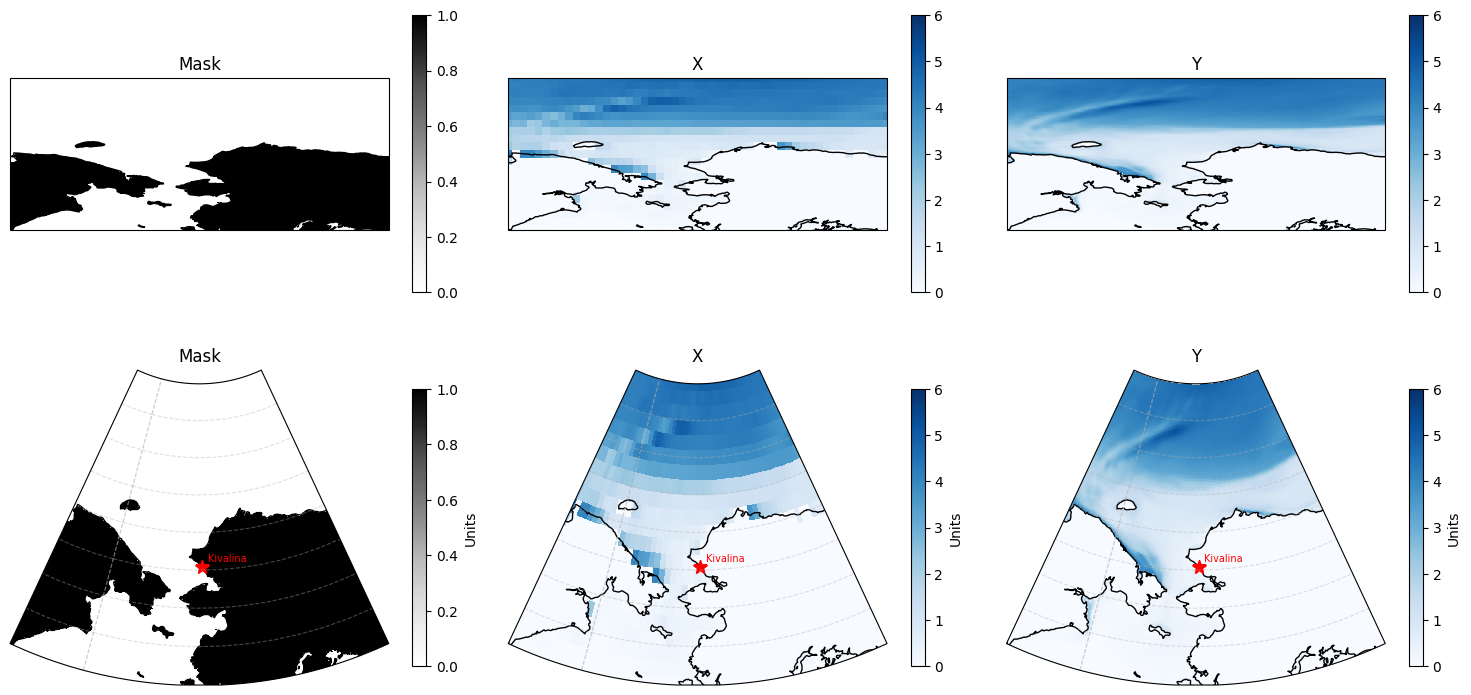

In [14]:
# ---- Projection setup ----
bbox = {"lon_min": -190, "lon_max": -140, "lat_min": 60, "lat_max": 80}
lon_min = bbox["lon_min"] % 360
lon_max = bbox["lon_max"] % 360
kivalina_lat = 67.7269
kivalina_lon_360 = -164.5333 % 360
central_lon = (bbox["lon_min"] + bbox["lon_max"]) / 2
proj = ccrs.NorthPolarStereo(central_longitude=central_lon)

n = 50
lons = np.concatenate([
    np.linspace(bbox["lon_min"], bbox["lon_max"], n),
    np.full(n, bbox["lon_max"]),
    np.linspace(bbox["lon_max"], bbox["lon_min"], n),
    np.full(n, bbox["lon_min"]),
])
lats = np.concatenate([
    np.full(n, bbox["lat_min"]),
    np.linspace(bbox["lat_min"], bbox["lat_max"], n),
    np.full(n, bbox["lat_max"]),
    np.linspace(bbox["lat_max"], bbox["lat_min"], n),
])
boundary_pts = proj.transform_points(ccrs.PlateCarree(), lons, lats)
boundary_path = mpath.Path(boundary_pts[:, :2])

fig = plt.figure(figsize=(15, 8))
levels = np.linspace(0, 6, 7)

# ---- Row 1: flat lon/lat panels ----
flat_proj = ccrs.PlateCarree(central_longitude=central_lon)

ax1 = fig.add_subplot(2, 3, 1, projection=flat_proj)
cf1 = ax1.pcolormesh(hlon, hlat, land_mask[0, 0], cmap="Greys", vmin=0, vmax=1, shading="auto", transform=ccrs.PlateCarree())
ax1.coastlines(resolution="50m")
ax1.set_extent([lon_min, lon_max, bbox["lat_min"], bbox["lat_max"]], crs=ccrs.PlateCarree())
fig.colorbar(cf1, ax=ax1, shrink=0.7)
ax1.set_title("Mask")

ax2 = fig.add_subplot(2, 3, 2, projection=flat_proj)
cf2 = ax2.pcolormesh(llon, llat, X[0, 0, 0], cmap="Blues", vmin=0, vmax=6, shading="auto", transform=ccrs.PlateCarree())
ax2.coastlines(resolution="50m")
ax2.set_extent([lon_min, lon_max, bbox["lat_min"], bbox["lat_max"]], crs=ccrs.PlateCarree())
fig.colorbar(cf2, ax=ax2, shrink=0.7)
ax2.set_title("X")

ax3 = fig.add_subplot(2, 3, 3, projection=flat_proj)
cf3 = ax3.pcolormesh(hlon, hlat, Y[0, 0, 0], cmap="Blues", vmin=0, vmax=6, shading="auto", transform=ccrs.PlateCarree())
ax3.coastlines(resolution="50m")
ax3.set_extent([lon_min, lon_max, bbox["lat_min"], bbox["lat_max"]], crs=ccrs.PlateCarree())
fig.colorbar(cf3, ax=ax3, shrink=0.7)
ax3.set_title("Y")

# ---- Row 2: NorthPolarStereo projection ----
proj_panels = [
    (hlon, hlat, land_mask[0, 0], "Mask", "Greys", 0, 1),
    (llon, llat, X[0, 0, 0], "X", "Blues", 0, 6),
    (hlon, hlat, Y[0, 0, 0], "Y", "Blues", 0, 6),
]

for i, (lon_i, lat_i, field, title, cmap, vmin, vmax) in enumerate(proj_panels):
    ax = fig.add_subplot(2, 3, 4 + i, projection=proj)
    cf = ax.pcolormesh(
        lon_i, lat_i, field,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading="auto",
    )
    ax.coastlines(resolution="50m")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.set_extent([lon_min, lon_max, bbox["lat_min"], bbox["lat_max"]], crs=ccrs.PlateCarree())
    ax.set_boundary(boundary_path, transform=proj)
    ax.plot(kivalina_lon_360, kivalina_lat, marker="*", color="red", markersize=10, transform=ccrs.PlateCarree())
    ax.text(kivalina_lon_360 + 1, kivalina_lat + 0.35, "Kivalina", color="red", fontsize=7, transform=ccrs.PlateCarree())
    ax.gridlines(draw_labels=False, linestyle="--", alpha=0.4)
    ax.set_title(title, fontsize=12)
    plt.colorbar(cf, ax=ax, shrink=0.7, label="Units")

plt.tight_layout()
plt.show()

In [18]:
# ------------------------------
# Patch Extraction
# ------------------------------

def extract_patches(X, Y, land_mask, context_size, target_size, stride):
    N, C, H, W = X.shape
    _, C_out, H_hi, W_hi = Y.shape
    context_h, context_w = context_size
    target_h, target_w = target_size

    if context_h > H or context_w > W:
        raise ValueError(f"Context size {context_size} exceeds LR grid size ({H}, {W})")
    if target_h > context_h or target_w > context_w:
        raise ValueError(f"Target size {target_size} must be <= context size {context_size}")

    scale_y = H_hi / H
    scale_x = W_hi / W
    pad_h = (context_h - target_h) // 2
    pad_w = (context_w - target_w) // 2

    # land_mask is static across n, so compute each tile's geometry + mask
    # crop once, then just reuse it inside the per-sample loop
    tiles = []
    for i in range(0, H - context_h + 1, stride):
        for j in range(0, W - context_w + 1, stride):
            y0 = round((i + pad_h) * scale_y)
            x0 = round((j + pad_w) * scale_x)
            y1 = y0 + int(round(target_h * scale_y))
            x1 = x0 + int(round(target_w * scale_x))
            mask_patch = land_mask[0, :, y0:y1, x0:x1]  # (C_mask, target_h, target_w)
            tiles.append((i, j, y0, x0, y1, x1, mask_patch))

    X_patches, Y_patches, mask_patches = [], [], []
    for n in range(N):
        for (i, j, y0, x0, y1, x1, mask_patch) in tiles:
            X_patches.append(X[n, :, i:i + context_h, j:j + context_w])
            Y_patches.append(Y[n, :, y0:y1, x0:x1])
            mask_patches.append(mask_patch)

    X_patches = torch.stack(X_patches)
    Y_patches = torch.stack(Y_patches)
    mask_patches = torch.stack(mask_patches)
    return X_patches, Y_patches, mask_patches


# ------------------------------
# Train/Test Split
# ------------------------------

N, T, C, H, W = X.shape

X_fields = torch.tensor(X.reshape(N * T, C, H, W)).float()
Y_fields = torch.tensor(Y.reshape(N * T, 1, Y.shape[3], Y.shape[4])).float()

indices = torch.randperm(N * T)
split = int(0.8 * N * T)

train_idx = indices[:split]
test_idx = indices[split:]

X_train_fields = X_fields[train_idx]
Y_train_fields = Y_fields[train_idx]
X_test_fields = X_fields[test_idx]
Y_test_fields = Y_fields[test_idx]

# ------------------------------
# Normalize
# ------------------------------

X_mean = X_train_fields.mean(dim=(0, 2, 3), keepdim=True)
X_std = X_train_fields.std(dim=(0, 2, 3), keepdim=True)
Y_mean = Y_train_fields.mean(dim=(0, 2, 3), keepdim=True)
Y_std = Y_train_fields.std(dim=(0, 2, 3), keepdim=True)

X_train = (X_train_fields - X_mean) / (X_std + 1e-6)
X_test = (X_test_fields - X_mean) / (X_std + 1e-6)
Y_train = (Y_train_fields - Y_mean) / (Y_std + 1e-6)
Y_test = (Y_test_fields - Y_mean) / (Y_std + 1e-6)

# ------------------------------
# Extract Patches
# ------------------------------

context_size = (16, 24)
target_size = (8, 12)
stride = 4

X_train, Y_train, mask_train = extract_patches(X_train, Y_train, land_mask, context_size, target_size, stride)
X_test, Y_test, mask_test = extract_patches(X_test, Y_test, land_mask, context_size, target_size, stride)

print("X_train:   ", X_train.shape)
print("Y_train:   ", Y_train.shape)
print("mask_train:", mask_train.shape)
print("X_test:    ", X_test.shape)
print("Y_test:    ", Y_test.shape)
print("mask_test: ", mask_test.shape)

X_train:    torch.Size([115584, 4, 16, 24])
Y_train:    torch.Size([115584, 1, 76, 118])
mask_train: torch.Size([115584, 1, 76, 118])
X_test:     torch.Size([28896, 4, 16, 24])
Y_test:     torch.Size([28896, 1, 76, 118])
mask_test:  torch.Size([28896, 1, 76, 118])


#### Model setup

In [21]:
# ------------------------------
# UNet
# ------------------------------

def smooth_noise(z):
    return F.avg_pool2d(z, kernel_size=3, stride=1, padding=1)


class UNet(nn.Module):

    def __init__(self, in_channels, latent_channels=8, mask_channels=1):

        super().__init__()
        self.latent_channels = latent_channels

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.InstanceNorm2d(out_c, affine=True),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.InstanceNorm2d(out_c, affine=True),
                nn.ReLU(inplace=True),
            )

        # ------------------------------
        # Encoder
        # ------------------------------

        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = conv_block(256, 512)

        # ------------------------------
        # Bottleneck
        # ------------------------------

        self.bottleneck = conv_block(512, 512)

        # ------------------------------
        # Decoder
        # ------------------------------

        self.up3 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), nn.Conv2d(512, 256, 3, padding=1))
        self.dec3 = conv_block(512, 256)

        self.up2 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), nn.Conv2d(256, 128, 3, padding=1))
        self.dec2 = conv_block(256, 128)

        self.up1 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), nn.Conv2d(128, 64, 3, padding=1))
        self.dec1 = conv_block(128, 64)

        # Decoder noise projections
        self.z_proj_d3 = nn.Conv2d(latent_channels, 256, 1)
        self.z_proj_d2 = nn.Conv2d(latent_channels, 128, 1)
        self.z_proj_d1 = nn.Conv2d(latent_channels, 64, 1)

        # Scaling for additive noise
        self.noise_scale_d3 = nn.Parameter(torch.tensor(0.05))
        self.noise_scale_d2 = nn.Parameter(torch.tensor(0.05))
        self.noise_scale_d1 = nn.Parameter(torch.tensor(0.05))

        # Concatenation adapters
        self.concat_d3 = nn.Conv2d(256 + 256, 256, 1)
        self.concat_d2 = nn.Conv2d(128 + 128, 128, 1)
        self.concat_d1 = nn.Conv2d(64 + 64, 64, 1)

        # ------------------------------
        # Output
        # ------------------------------
        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=4)
        self.mask_fuse = nn.Sequential(nn.Conv2d(32 + mask_channels, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.out_conv = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x, up_size, mask=None, z=None):

        B, C, H, W = x.shape

        # Latent noise
        if z is None:
            z = torch.randn(B, self.latent_channels, H // 8, W // 8, device=x.device)
            z = smooth_noise(z)

        # ------------------------------
        # Encoder
        # ------------------------------

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        # ------------------------------
        # Bottleneck
        # ------------------------------

        b = self.bottleneck(e4)

        # ------------------------------
        # Decoder
        # ------------------------------

        d3 = self.up3(b)
        zd3 = F.interpolate(z, size=d3.shape[-2:], mode="bilinear", align_corners=False)
        zd3 = self.z_proj_d3(zd3)
        d3 = self.concat_d3(torch.cat([d3, zd3], dim=1))
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        zd2 = F.interpolate(z, size=d2.shape[-2:], mode="bilinear", align_corners=False)
        zd2 = self.z_proj_d2(zd2)
        d2 = self.concat_d2(torch.cat([d2, zd2], dim=1))
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        zd1 = F.interpolate(z, size=d1.shape[-2:], mode="bilinear", align_corners=False)
        zd1 = self.z_proj_d1(zd1)
        d1 = self.concat_d1(torch.cat([d1, zd1], dim=1))
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # ------------------------------
        # Output
        # ------------------------------

        out = self.final_up(d1)
        out = F.interpolate(out, size=up_size, mode="bilinear", align_corners=False)

        if mask is not None:
            if mask.dim() == 3:
                mask = mask.unsqueeze(1)
            out = self.mask_fuse(torch.cat([out, mask.to(out.dtype)], dim=1))

        out = self.out_conv(out)
        out = F.interpolate(out, size=up_size, mode="bilinear", align_corners=False)

        # Residual prediction
        base = F.interpolate(x[:, 0:1], size=up_size, mode="bilinear", align_corners=False)

        return base + out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=X_train.shape[1], latent_channels=8, mask_channels=mask_train.shape[1])
model = nn.DataParallel(model).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("Model setup complete.")

Model setup complete.


#### Training loop (Engression)

In [24]:
def energy_loss(preds, y, beta=1.0):
    """
    Energy-score loss used for stochastic prediction.

    Args:
        preds (torch.Tensor): Ensemble predictions of shape [B, K, C, H, W], where B is batch size and K is the number of stochastic samples.
        y (torch.Tensor): Ground-truth targets of shape [B, C, H, W].
        beta (float, optional): Power parameter of the energy score. Default is 1.

    Returns:
        torch.Tensor: Scalar energy-score loss.
    """

    B, K, C, H, W = preds.shape

    flat_preds = preds.reshape(B, K, -1)
    flat_y = y.reshape(B, 1, -1)

    EPS = 0.0 if float(beta).is_integer() else 1e-5

    # Average distance between each ensemble member and truth
    s1 = (torch.linalg.vector_norm(flat_preds - flat_y, ord=2, dim=2) + EPS).pow(beta).mean()

    # Average pairwise distance between ensemble members
    s2 = (torch.cdist(flat_preds, flat_preds, p=2) + EPS).pow(beta).mean() * K/(K-1)

    return s1 - 0.5 * s2


def land_loss(preds, land_mask, y_mean, y_std):
    """
    Penalize positive (physical) ice thickness predicted over land.
    """
    land_mask = land_mask.to(preds.device).unsqueeze(1)
    y_mean = y_mean.to(preds.device).unsqueeze(1)
    y_std = y_std.to(preds.device).unsqueeze(1)
    preds_physical = preds * y_std + y_mean
    return ((torch.relu(preds_physical) * land_mask) ** 2).mean()


# ------------------------------
# Training loop
# ------------------------------

K, num_epochs, batch_size = 6, 20, 32
loss_array = []

for epoch in range(num_epochs):

    model.train()
    epoch_loss = 0.0
    idx = torch.randperm(X_train.size(0))

    for i in range(0, X_train.size(0), batch_size):

        optimizer.zero_grad()

        batch_idx = idx[i:i + batch_size]
        X_batch = X_train[batch_idx].to(device)
        Y_batch = Y_train[batch_idx].to(device)
        mask_batch = mask_train[batch_idx].to(device)

        B, C, H, W = X_batch.shape

        # Stochastic ensemble
        X_rep = X_batch.repeat_interleave(K, dim=0)
        mask_rep = mask_batch.repeat_interleave(K, dim=0)

        preds = model(X_rep, up_size=Y_batch.shape[-2:], mask=mask_rep)
        preds = preds.reshape(B, K, preds.shape[1], preds.shape[2], preds.shape[3])

        # Loss
        loss = energy_loss(preds, Y_batch)

        # Backprop
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        epoch_loss += loss.item() * B

        del X_batch, Y_batch, mask_batch, X_rep, mask_rep, preds, loss

    epoch_loss /= X_train.size(0)
    loss_array.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.6f}")

Epoch 1/20 | Loss: 13.184872
Epoch 2/20 | Loss: 8.905588
Epoch 3/20 | Loss: 7.999039


KeyboardInterrupt: 

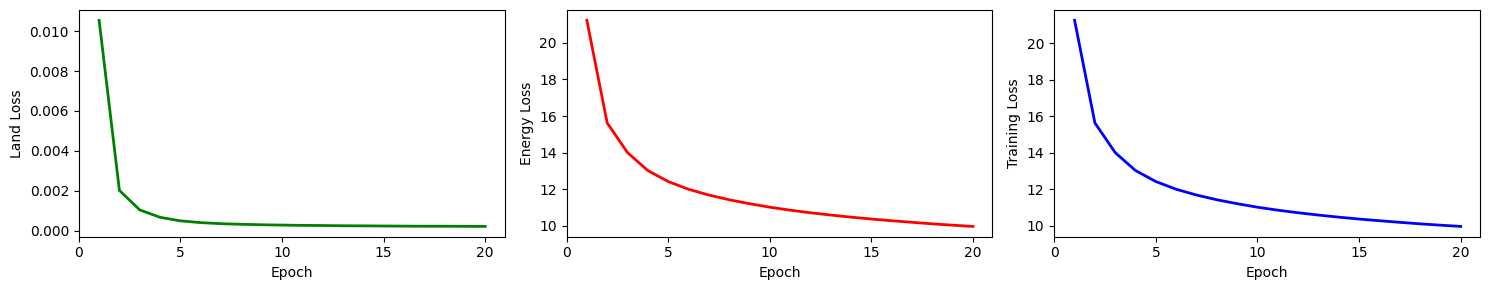

In [7]:
# ------------------------------
# Loss curve
# ------------------------------

epochs = np.arange(1, len(loss_array) + 1)

norm_factor = np.sqrt(np.prod(Y_train.shape[1:]))
loss_array_scaled = np.array(loss_array) / norm_factor

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot(epochs, loss_array_scaled, linewidth=2, color='blue')
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss (per-pixel scale)")
ax.set_xticks(np.arange(0, len(loss_array) + 1, 5))
plt.tight_layout()
plt.show()

In [8]:
# ------------------------------
# Evaluation
# ------------------------------

model.eval()
batch_size = 16
K_eval = 6

preds_all = []
preds_mean = []
preds_std = []
preds_det = []

with torch.inference_mode():
    for i in range(0, X_test.shape[0], batch_size):
        X_batch = X_test[i:i + batch_size].to(device)
        Y_batch = Y_test[i:i + batch_size].to(device)
        mask_batch = mask_test[i:i + batch_size].to(device)
        B, _, H, W = X_batch.shape

        # Stochastic ensemble
        ensemble_preds = []
        for k in range(K_eval):
            z = torch.randn(B, model.module.latent_channels, H // 8, W // 8, device=device)
            z = smooth_noise(z)
            pred = model(X_batch, Y_batch.shape[-2:], mask=mask_batch, z=z)
            ensemble_preds.append(pred)

        preds = torch.stack(ensemble_preds, dim=0)
        preds = preds.permute(1, 0, 2, 3, 4)

        # Ensemble statistics
        pred_mean = preds.mean(dim=1)
        pred_std = preds.std(dim=1)

        # Deterministic prediction (z = 0, smoothing is a no-op here)
        z0 = torch.zeros(B, model.module.latent_channels, H // 8, W // 8, device=device)
        pred_det = model(X_batch, Y_batch.shape[-2:], mask=mask_batch, z=z0)

        preds_all.append(preds.cpu())
        preds_mean.append(pred_mean.cpu())
        preds_std.append(pred_std.cpu())
        preds_det.append(pred_det.cpu())

# Concatenate
preds_all = torch.cat(preds_all, dim=0)
Y_pred = torch.cat(preds_mean, dim=0)
Y_spread = torch.cat(preds_std, dim=0)
Y_pred_det = torch.cat(preds_det, dim=0)

# Convert back to physical units
Y_test_phys = Y_test * Y_std + Y_mean
Y_pred_phys = (Y_pred * Y_std + Y_mean).clamp(min=0.0)
Y_spread_phys = Y_spread * Y_std
Y_pred_det_phys = (Y_pred_det * Y_std + Y_mean).clamp(min=0.0)
preds_all_phys = (preds_all * Y_std + Y_mean).clamp(min=0.0)

# Bilinear baseline
sit_idx = 0
X_test_sit_phys = X_test[:, sit_idx:sit_idx + 1] * X_std[:, sit_idx:sit_idx + 1] + X_mean[:, sit_idx:sit_idx + 1]
Y_base_phys = F.interpolate(X_test_sit_phys, size=Y_test.shape[-2:], mode="bilinear", align_corners=False).cpu()

print('Inference complete.')

Done!


In [9]:
# ------------------------------
# Metrics
# ------------------------------

def mae(pred, truth):
    return torch.mean(torch.abs(pred - truth)).item()


def rmse(pred, truth):
    return torch.sqrt(torch.mean((pred - truth) ** 2)).item()


def bias(pred, truth):
    return torch.mean(pred - truth).item()


def grad_mae(pred, truth):
    dx_p = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dx_t = truth[:, :, :, 1:] - truth[:, :, :, :-1]
    dy_p = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    dy_t = truth[:, :, 1:, :] - truth[:, :, :-1, :]
    grad_error = torch.mean(torch.abs(dx_p - dx_t)) + torch.mean(torch.abs(dy_p - dy_t))
    return grad_error.item()


def pattern_corr(pred, truth):
    """
    Per-sample Pearson correlation between predicted and true spatial
    fields, averaged across samples. Captures spatial structure independent
    of magnitude bias.
    """
    B = pred.shape[0]
    p = pred.reshape(B, -1)
    t = truth.reshape(B, -1)
    p = p - p.mean(dim=1, keepdim=True)
    t = t - t.mean(dim=1, keepdim=True)
    num = (p * t).sum(dim=1)
    den = torch.sqrt((p ** 2).sum(dim=1) * (t ** 2).sum(dim=1)) + 1e-8
    return (num / den).mean().item()


def spread_skill_ratio(pred_mean, pred_std, truth):
    error = torch.abs(pred_mean - truth)
    return (pred_std.mean() / error.mean()).item()


def _gaussian_window(window_size, sigma, device):
    coords = torch.arange(window_size, dtype=torch.float32, device=device) - window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    return g.outer(g)


def ssim(pred, truth, window_size=11, sigma=1.5, data_range=None):
    """
    Structural similarity index (Wang et al., 2004). Complements Grad MAE
    with a standard windowed structural/perceptual metric, widely reported
    alongside PSNR in the super-resolution / downscaling literature.
    """
    device = pred.device
    C = pred.shape[1]
    if data_range is None:
        data_range = (truth.max() - truth.min()).clamp(min=1e-6)

    window = _gaussian_window(window_size, sigma, device)
    window = window.expand(C, 1, window_size, window_size).contiguous()
    pad = window_size // 2

    mu_p = F.conv2d(pred, window, padding=pad, groups=C)
    mu_t = F.conv2d(truth, window, padding=pad, groups=C)
    mu_p_sq, mu_t_sq, mu_pt = mu_p ** 2, mu_t ** 2, mu_p * mu_t

    sigma_p_sq = F.conv2d(pred * pred, window, padding=pad, groups=C) - mu_p_sq
    sigma_t_sq = F.conv2d(truth * truth, window, padding=pad, groups=C) - mu_t_sq
    sigma_pt = F.conv2d(pred * truth, window, padding=pad, groups=C) - mu_pt

    k1, k2 = 0.01, 0.03
    C1, C2 = (k1 * data_range) ** 2, (k2 * data_range) ** 2

    ssim_map = ((2 * mu_pt + C1) * (2 * sigma_pt + C2)) / ((mu_p_sq + mu_t_sq + C1) * (sigma_p_sq + sigma_t_sq + C2))
    return ssim_map.mean().item()


def ice_edge_error(pred, truth, threshold=0.0):
    """
    Integrated Ice Edge Error (IIEE; Goessling et al., 2016), adapted for a
    thickness field: fraction of domain pixels where the predicted and true
    binary ice masks (SIT > threshold) disagree, combining overestimation
    (ice predicted where there is none) and underestimation (ice missed).
    Reported here as a fraction of domain pixels (0 = perfect edge
    placement); the literature version weights by physical cell area, which
    would need the POP grid's TAREA regridded the same way as land_mask.
    """
    ice_pred = (pred > threshold).float()
    ice_truth = (truth > threshold).float()
    overestimate = (ice_pred * (1 - ice_truth)).sum()
    underestimate = ((1 - ice_pred) * ice_truth).sum()
    return ((overestimate + underestimate) / torch.numel(pred)).item()


metrics = [
    {
        "Method": "Bilinear",
        "MAE": mae(Y_base_phys, Y_test_phys),
        "RMSE": rmse(Y_base_phys, Y_test_phys),
        "Bias": bias(Y_base_phys, Y_test_phys),
        "Grad MAE": grad_mae(Y_base_phys, Y_test_phys),
        "Pattern Corr": pattern_corr(Y_base_phys, Y_test_phys),
        "SSIM": ssim(Y_base_phys, Y_test_phys),
        "IIEE": ice_edge_error(Y_base_phys, Y_test_phys),
        "Spread/Error": np.nan,
    }, {
        "Method": "Deterministic UNet",
        "MAE": mae(Y_pred_det_phys, Y_test_phys),
        "RMSE": rmse(Y_pred_det_phys, Y_test_phys),
        "Bias": bias(Y_pred_det_phys, Y_test_phys),
        "Grad MAE": grad_mae(Y_pred_det_phys, Y_test_phys),
        "Pattern Corr": pattern_corr(Y_pred_det_phys, Y_test_phys),
        "SSIM": ssim(Y_pred_det_phys, Y_test_phys),
        "IIEE": ice_edge_error(Y_pred_det_phys, Y_test_phys),
        "Spread/Error": np.nan,
    }, {
        "Method": "Stochastic UNet Mean",
        "MAE": mae(Y_pred_phys, Y_test_phys),
        "RMSE": rmse(Y_pred_phys, Y_test_phys),
        "Bias": bias(Y_pred_phys, Y_test_phys),
        "Grad MAE": grad_mae(Y_pred_phys, Y_test_phys),
        "Pattern Corr": pattern_corr(Y_pred_phys, Y_test_phys),
        "SSIM": ssim(Y_pred_phys, Y_test_phys),
        "IIEE": ice_edge_error(Y_pred_phys, Y_test_phys),
        "Spread/Error": spread_skill_ratio(Y_pred_phys, Y_spread_phys, Y_test_phys),
    }
]

metrics_df = pd.DataFrame(metrics).round(4)
print(metrics_df)

                 Method     MAE    RMSE  Grad MAE  Spread/Error
0              Bilinear  3.1063  5.4299    1.5571           NaN
1    Deterministic UNet  0.6794  1.2131    1.2326           NaN
2  Stochastic UNet Mean  0.5795  1.0766    1.0535        1.2233


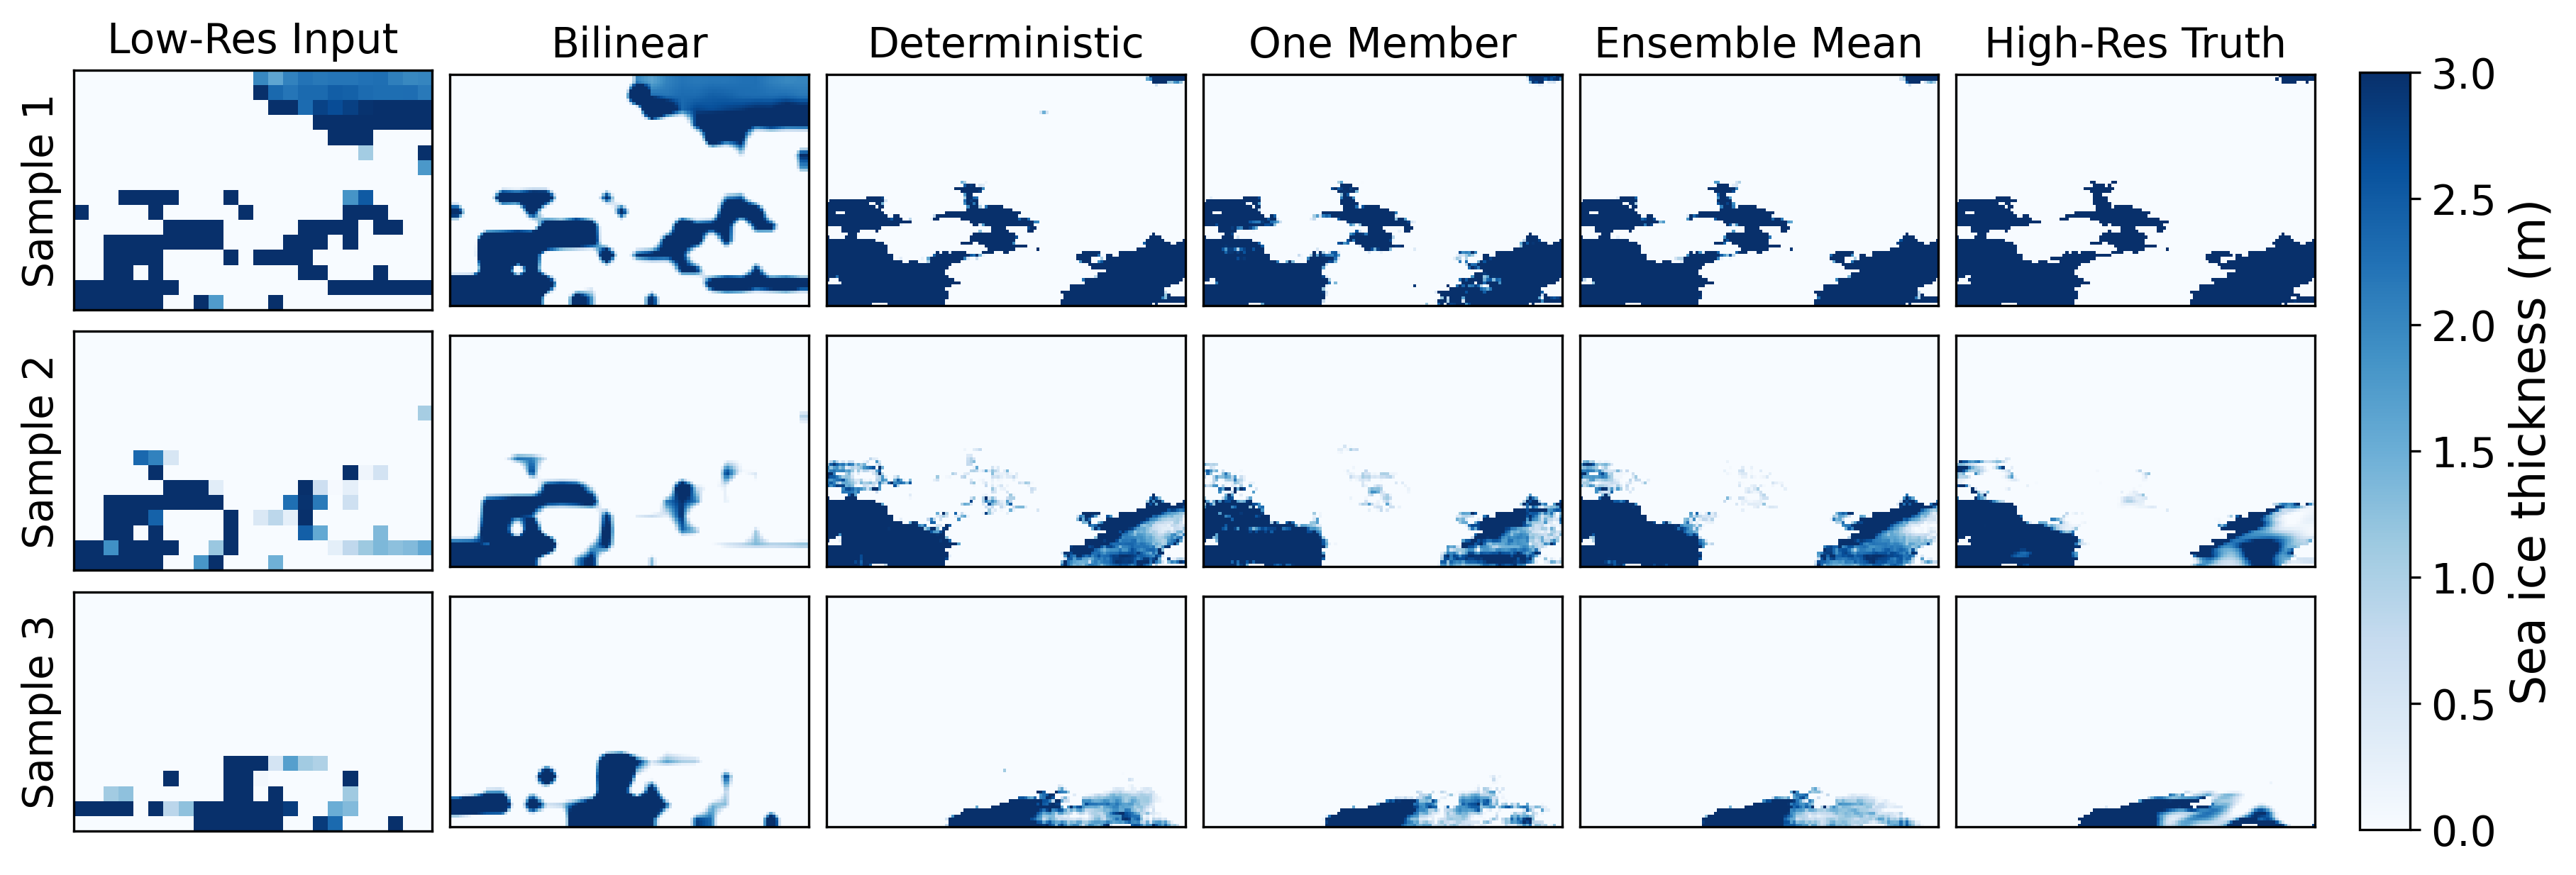

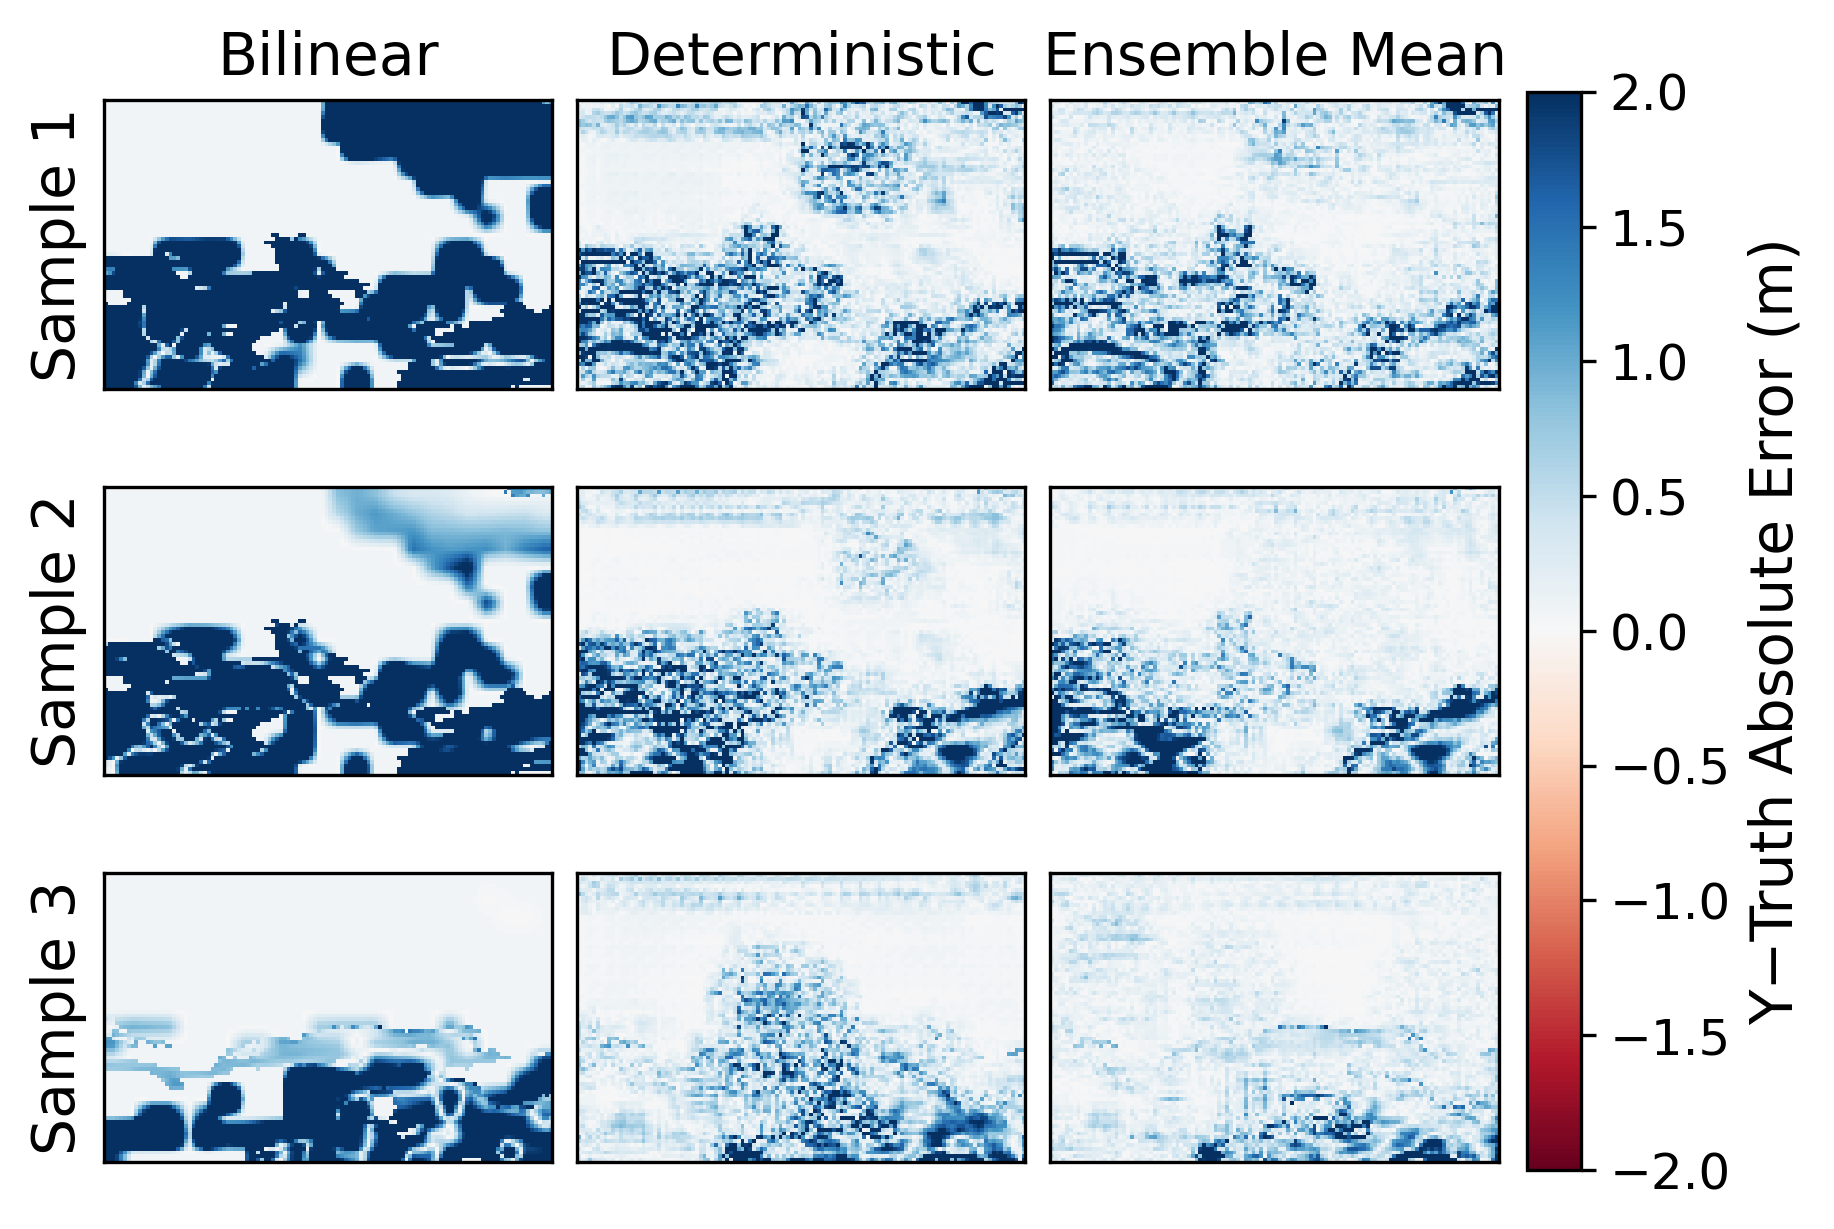

In [10]:
# ------------------------------
# Ensemble Figure
# ------------------------------

mem_idx = 4
num_samples = 3
idxs = np.random.choice(X_test.shape[0], num_samples, replace=False)

fig, axs = plt.subplots(3, 6, figsize=(12, 4), constrained_layout=True, dpi=300)

for row, idx in enumerate(idxs):

    lowres = X_test_sit_phys[idx, 0]
    bilinear = Y_base_phys[idx, 0]
    deterministic = Y_pred_det_phys[idx, 0]
    ens_full = preds_all_phys[idx]
    ens_mean = Y_pred_phys[idx, 0]
    truth = Y_test_phys[idx, 0]

    # Low-res
    im = axs[row, 0].imshow(lowres, cmap='Blues', vmin=0, vmax=3)
    axs[0, 0].set_title("Low-Res Input", fontsize=14)

    # Bilinear
    axs[row, 1].imshow(bilinear, cmap='Blues', vmin=0, vmax=3)
    axs[0, 1].set_title("Bilinear", fontsize=14)

    # Deterministic
    axs[row, 2].imshow(deterministic, cmap='Blues', vmin=0, vmax=3)
    axs[0, 2].set_title("Deterministic", fontsize=14)

    # Ensemble member
    axs[row, 3].imshow(ens_full[mem_idx, 0], cmap='Blues', vmin=0, vmax=3)
    axs[0, 3].set_title("One Member", fontsize=14)

    # Ensemble mean
    axs[row, 4].imshow(ens_mean, cmap='Blues', vmin=0, vmax=3)
    axs[0, 4].set_title("Ensemble Mean", fontsize=14)

    # Truth
    axs[row, 5].imshow(truth, cmap='Blues', vmin=0, vmax=3)
    axs[0, 5].set_title("High-Res Truth", fontsize=14)

    for col in range(6):
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])

    axs[0, 0].set_ylabel('Sample 1', fontsize=14)
    axs[1, 0].set_ylabel('Sample 2', fontsize=14)
    axs[2, 0].set_ylabel('Sample 3', fontsize=14)

cbar = fig.colorbar(im, ax=axs, aspect=15, shrink=0.99, pad=0.02)
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Sea ice thickness (m)", fontsize=16)

plt.show()

In [ ]:
# ------------------------------
# Error Figure
# ------------------------------

fig, axs = plt.subplots(3, 3, figsize=(6, 4), constrained_layout=True, dpi=300)

for row, idx in enumerate(idxs):

    bilinear = Y_base_phys[idx, 0].numpy()
    det = Y_pred_det_phys[idx, 0].numpy()
    ens = Y_pred_phys[idx, 0].numpy()
    truth = Y_test_phys[idx, 0].numpy()

    bilinear_ae = abs(bilinear - truth)
    det_ae = abs(det - truth)
    ens_ae = abs(ens - truth)

    im = axs[row, 0].imshow(bilinear_ae, cmap='viridis', vmin=0, vmax=2)
    axs[0, 0].set_title("Bilinear", fontsize=14)

    axs[row, 1].imshow(det_ae, cmap='viridis', vmin=0, vmax=2)
    axs[0, 1].set_title("Deterministic", fontsize=14)

    axs[row, 2].imshow(ens_ae, cmap='viridis', vmin=0, vmax=2)
    axs[0, 2].set_title("Ensemble Mean", fontsize=14)

    for col in range(3):
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])

    axs[0, 0].set_ylabel('Sample 1', fontsize=14)
    axs[1, 0].set_ylabel('Sample 2', fontsize=14)
    axs[2, 0].set_ylabel('Sample 3', fontsize=14)

cbar = fig.colorbar(im, ax=axs, aspect=20, shrink=0.95, pad=0.02)
cbar.ax.tick_params(labelsize=12)
cbar.set_label("|Y − Truth| Absolute Error (m)", fontsize=14)
plt.show()

#### Training loop (normal)

In [ ]:
# ------------------------------
# Training Loop
# ------------------------------

num_epochs = 20
batch_size = 16
loss_array = []

for epoch in range(num_epochs):

    model.train()
    epoch_loss = 0.0

    idx = torch.randperm(X_train.size(0))

    for i in range(0, X_train.size(0), batch_size):

        optimizer.zero_grad()

        batch_idx = idx[i:i+batch_size]
        X_batch = X_train[batch_idx].to(device, non_blocking=True)
        Y_batch = Y_train[batch_idx].to(device, non_blocking=True)
        Y_pred = model(X_batch, Y_batch.shape[-2:])

        if USE_MASKED_LOSS:
            mask_batch = F.interpolate(
                mask,
                size=Y_batch.shape[-2:],
                mode='nearest'
            )
            mask_batch = mask_batch.expand(Y_batch.size(0), 1, -1, -1).to(device)
            loss = masked_loss(Y_pred, Y_batch, mask_batch)
        else:
            loss = base_loss(Y_pred, Y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)

        # Clean up after loop
        del X_batch, Y_batch, Y_pred, loss

    epoch_loss /= X_train.size(0)
    loss_array.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.6f}")

epochs = np.arange(1, len(loss_array)+1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, loss_array, marker='o', linestyle='-', color='C0', linewidth=2, markersize=6, label='Training Loss')

plt.title('UNet Training Loss per Epoch', fontsize=12)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.xticks(epochs)
plt.xlim(0.5, len(epochs)+0.5)
plt.grid(alpha=0.25)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------
# Evaluation
# ------------------------------
model.eval()
batch_size = 16
preds = []

with torch.inference_mode():
    for i in range(0, X_test.shape[0], batch_size):

        X_batch = X_test[i:i+batch_size].to(device)
        Y_batch = Y_test[i:i+batch_size]

        Y_pred_batch = model(X_batch, Y_batch.shape[-2:])
        preds.append(Y_pred_batch.cpu())

Y_pred = torch.cat(preds, dim=0)
Y_pred_phys = Y_pred * Y_std + Y_mean
Y_test_phys = Y_test * Y_std + Y_mean

# ------------------------------
# Bilinear baseline
# ------------------------------
sit_idx = 0

X_test_sit_phys = (
    X_test[:, sit_idx:sit_idx+1] * X_std[:, sit_idx:sit_idx+1]
    + X_mean[:, sit_idx:sit_idx+1]
)

base = F.interpolate(
    X_test_sit_phys,
    size=Y_test.shape[-2:],
    mode="bilinear",
    align_corners=False
)

# ------------------------------
# Metrics
# ------------------------------
mse_cnn = ((Y_pred_phys - Y_test_phys)**2).mean().item()
mse_base = ((base - Y_test_phys)**2).mean().item()


def spatial_corr(y_true, y_pred):
    y_true_flat = y_true.reshape(y_true.shape[0], -1)
    y_pred_flat = y_pred.reshape(y_pred.shape[0], -1)

    corrs = []
    valid = 0
    total = y_true.shape[0]

    for i in range(y_true.shape[0]):

        std_true = np.std(y_true_flat[i])
        std_pred = np.std(y_pred_flat[i])

        # Skip bad patches
        if std_true > 0 and std_pred > 0:
            valid += 1
            corrs.append(np.corrcoef(y_true_flat[i], y_pred_flat[i])[0, 1])

    print(f"Valid patches: {valid}/{total}")

    return np.nanmean(corrs)


corr_cnn = spatial_corr(
    Y_test_phys.cpu().numpy(),
    Y_pred_phys.cpu().numpy()
)

corr_base = spatial_corr(
    Y_test_phys.cpu().numpy(),
    base.cpu().numpy()
)

print(f"\nCNN Test MSE         : {mse_cnn:.4f}")
print(f"Bilinear baseline MSE: {mse_base:.4f}")
print(f"\nCNN Test spatial correlation         : {corr_cnn:.4f}")
print(f"Bilinear baseline spatial correlation: {corr_base:.4f}")

In [ ]:
# ------------------------------
# Random samples for plotting
# ------------------------------
num_samples = 3
idxs = np.random.choice(X_test.shape[0], num_samples, replace=False)
cmap = 'Blues'
vmin, vmax = 0, 4

fig, axs = plt.subplots(num_samples, 4, figsize=(10, 6), constrained_layout=True)

for i, idx in enumerate(idxs):
    axs[i, 0].imshow(X_test[idx, 0].cpu(), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[i, 1].imshow(base[idx, 0].cpu(), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[i, 2].imshow(Y_pred_phys[idx, 0].cpu(), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[i, 3].imshow(Y_test_phys[idx, 0].cpu(), vmin=vmin, vmax=vmax, cmap=cmap)
    for j in range(4):
        axs[i, j].axis('off')

axs[0, 0].set_title("Low-res Input")
axs[0, 1].set_title("Bilinear Interpolation")
axs[0, 2].set_title("UNet Prediction")
axs[0, 3].set_title("Hi-res Truth")

fig.colorbar(axs[0, 0].images[0], ax=axs, shrink=0.95, aspect=35, label='Sea ice thickness (m)')
plt.show()